# Simulación *Péndulo Simple*
Sabemos que la ecuación diferencial del péndulo simple, puesto en su forma matricial es:
$$
\begin{bmatrix}
\dot{\theta} \\
\ddot{\theta}
\end{bmatrix}
=
\begin{bmatrix}
\dot{\theta} \\
-\frac{g\sin(\theta)}{L}
\end{bmatrix}
$$

<img src="./assets/Images/simple-pendulum.png" height="450" style="display:block; margin:auto;">

Colocando esto en código tenemos lo siguiente:

In [1]:
# Importación de librerías
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation

In [2]:
# Configuración de matplotlib 
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['legend.labelcolor'] = 'white'
plt.rcParams['xtick.labelcolor'] = 'white'
plt.rcParams['ytick.labelcolor'] = 'white'
plt.rcParams['grid.color'] = '#707070'

In [3]:
# Asignación de constantes y definición del sistema
g = 9.81  # aceleración debida a la gravedad (m/s^2)
L = 1.0   # longitud del péndulo (m)

theta0 = np.deg2rad(30)  # ángulo inicial (grados -> radianes)
theta_dot0 = 0  # velocidad angular inicial (rad/s)

Consideramos las siguientes condiciones iniciales:
$$
\theta(0) = \theta_0
$$
$$
\dot{\theta}(0) = \dot{\theta}_0
$$

Puesto en código:

In [4]:
def pendulo_ODE(t, y):
    return (y[1], -g*np.sin(y[0])/L)

sol = solve_ivp(pendulo_ODE, [0, 5], (theta0, theta_dot0),
    t_eval=np.linspace(0, 5, 30*5))

# Salida del código
theta = sol.y[0]
theta_dot = sol.y[1]
t = sol.t

# Convertimos a grados
theta_deg = np.degrees(theta)
theta_dot_deg = np.degrees(theta_dot)

Una vez que tenemos la solución numérica, podemos graficarla:

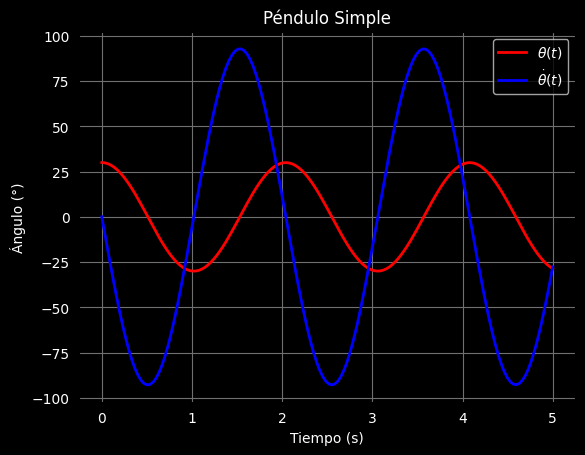

In [5]:
plt.plot(t, theta_deg, 'r', lw=2, label=r'$\theta(t)$')
plt.plot(t, theta_dot_deg, 'b', lw=2, label=r'$\dot{\theta}(t)$')

plt.title('Péndulo Simple')
plt.legend()
plt.xlabel('Tiempo (s)')
plt.ylabel('Ángulo (°)')
plt.grid(True)
plt.show()

Ahora creamos una animación simple

In [6]:
fig, ax = plt.subplots()

theta_curve, = ax.plot([], [], 'r', label=r"$\theta$")
theta_dot_curve, = ax.plot(t[0], theta_dot_deg[0], 'b', label=r"$\dot{\theta}$")

ax.set_title("Péndulo Simple: Posición y Velocidad Angular")
ax.set_xlim(0, 5)
ax.set_ylim(-100, 100)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel(r"$\theta$ (°), $\dot{\theta}$ (°/s)")
ax.legend([r"$\theta$", r"$\dot{\theta}$"])
ax.grid(True)

# Función animar
def animate(i):
    theta_curve.set_data(t[:i+1], theta_deg[:i+1])
    theta_dot_curve.set_data(t[:i+1], theta_dot_deg[:i+1])
    return theta_curve, theta_dot_curve

# Guardar video a 30 fps
animacion = animation.FuncAnimation(fig, animate, frames=len(t), interval=1000/30, blit=True)
writer = animation.PillowWriter(fps=30)
animacion.save('./assets/Pendulum/time_plot.gif', writer=writer)

plt.close(fig)

Ahora creamos un diagrama de fase.

Un diagrama de fase es una representación gráfica de la relación entre la posición y la velocidad angular del péndulo.

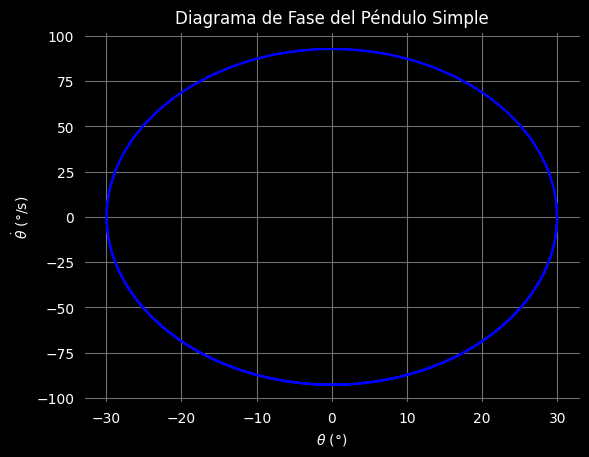

In [7]:
plt.plot(theta_deg, theta_dot_deg, 'b')
plt.title('Diagrama de Fase del Péndulo Simple')
plt.xlabel(r'$\theta$ (°)')
plt.ylabel(r'$\dot{\theta}$ (°/s)')
plt.grid(True)
plt.show()

In [8]:
# Animación del diagrama de fase
fig, ax = plt.subplots()

phase_curve, = ax.plot([], [], 'b')
phase_dot, = ax.plot(theta_deg[0], theta_dot_deg[0], 'ro')

ax.set_title('Diagrama de Fase')
ax.set_xlim(-35, 35)
ax.set_ylim(-100, 100)
ax.set_xlabel(r'$\theta$ (°)')
ax.set_ylabel(r"$\dot{\theta}$ (°/s)")
ax.grid(True)

def animate(i):
    phase_curve.set_data(theta_deg[:i+1], theta_dot_deg[:i+1])
    phase_dot.set_data([theta_deg[i]], [theta_dot_deg[i]])
    return phase_curve, phase_dot

# Guardar video a 30 fps
animacion = animation.FuncAnimation(fig, animate, frames=len(t), interval=1000/30, blit=True)
writer = animation.PillowWriter(fps=30)
animacion.save('./assets/Pendulum/phase_plot.gif', writer=writer)

plt.close(fig)

Por último, creamos la animación del movimiento del péndulo:

In [9]:
def pos_pend(theta):
    return (L * np.sin(theta), -L * np.cos(theta))

fig = plt.figure()
ax = fig.add_subplot(aspect='equal')
ax.set_xlim(-1, 1)
ax.set_ylim(-1.25, 0.25)
ax.grid(True)

x0, y0 = pos_pend(theta0)
line, = ax.plot([0, x0], [0, y0], lw=2, c='k')
circle = ax.add_patch(plt.Circle((x0, y0), 0.05, fc='r', zorder=3))

def animate(i):
    x, y = pos_pend(theta[i])
    line.set_data([0, x], [0, y])
    circle.center = (x, y)
    return line, circle

anim = animation.FuncAnimation(fig, animate, frames=len(t), interval=1000/30, blit=True)
writer = animation.PillowWriter(fps=30)
anim.save('./assets/Pendulum/simple_pendulum.gif', writer=writer)

plt.close(fig)

Ahora generamos el video con los datos de la simulación, juntando todo en uno mismo.

In [10]:
fig = plt.figure()
fig.suptitle('Todo del Péndulo Simple')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2], height_ratios=[1, 1])

ax0 = fig.add_subplot(gs[0, 0])
ax0.set_xlim(0, 5)
ax0.set_ylim(-100, 100)
ax0.set_ylabel(r'$\theta$ (°), $\dot{\theta}$ (°/s)')
ax0.legend([r'$\theta$', r'$\dot{\theta}$'])
ax0.grid(True)

theta_curve, = ax0.plot(t[0], theta_deg[0], 'b')
theta_dot_curve, = ax0.plot(t[0], theta_dot_deg[0], 'r')


ax1 = fig.add_subplot(gs[1, 0])
ax1.set_xlim(-100, 100)
ax1.set_ylim(-100, 100)
ax1.set_xlabel(r'$\theta$ (°)')
ax1.set_ylabel(r'$\dot{\theta}$ (°/s)')
ax1.grid(True)

phase_curve, = ax1.plot(theta_deg[0], theta_dot_deg[0], 'b')
phase_dot, = ax1.plot(theta_deg[0], theta_dot_deg[0], 'ro')

def pos_pend(theta):
    return (L * np.sin(theta), -L * np.cos(theta))

ax2 = fig.add_subplot(gs[:, 1])
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1.5, 0.5)

x0, y0 = pos_pend(theta[0])

line, = ax2.plot([0, x0], [0, y0], lw=2, c='k')
circle = ax2.add_patch(plt.Circle((x0, y0), 0.05, fc='r', zorder=5))

def animate(i):
    theta_curve.set_data(t[:i+1], theta_deg[:i+1])
    theta_dot_curve.set_data(t[:i+1], theta_dot_deg[:i+1])
    
    phase_curve.set_data(theta_deg[:i+1], theta_dot_deg[:i+1])
    phase_dot.set_data([theta_deg[i]], [theta_dot_deg[i]])
    
    x, y = pos_pend(theta[i])
    line.set_data([0, x], [0, y])
    circle.center = (x, y)
    
    return line, circle, theta_curve, theta_dot_curve, phase_curve, phase_dot

anim = animation.FuncAnimation(fig, animate, frames=len(t), interval=1000/30, blit=True)
writer = animation.PillowWriter(fps=30)
anim.save('./assets/Pendulum/all_sp.gif', writer=writer)

plt.close(fig)